# Analysis with astropy

In [35]:
%matplotlib widget

Import the necessary libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits 
from spectral_cube import SpectralCube
from astropy.visualization import make_lupton_rgb, ManualInterval, make_rgb, LogStretch
from astropy.modeling import models, fitting
import astropy.units as u
from astropy.wcs.utils import pixel_to_skycoord, proj_plane_pixel_scales

from mpdaf.obj import Cube, WCS, WaveCoord


Open the FITS file and check whats inside

In [3]:
file = fits.open('/home/polaris/nitrogen_mrk996/data/Mrk996.fits')
file.info()

Filename: /home/polaris/nitrogen_mrk996/data/Mrk996.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1811   ()      
  1  DATA          1 ImageHDU        44   (358, 357, 3681)   float32   
  2  STAT          1 ImageHDU        44   (358, 357, 3681)   float32   


The PRIMARY is empty.
The DATA has the spectra.
The STAT has the variances.

In [4]:
data_file = file[1]
stats_file = file[2]

file[1].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                  358 / length of data axis 1                          
NAXIS2  =                  357 / length of data axis 2                          
NAXIS3  =                 3681 / length of data axis 3                          
PCOUNT  =                    0 / required keyword; must = 0                     
GCOUNT  =                    1 / required keyword; must = 1                     
OBJECT  = 'Mrk996 (DATA)'                                                       
CRPIX1  =      157.48722028022 / Pixel coordinate of reference point            
CRPIX2  =     191.081028855458 / Pixel coordinate of reference point            
CD1_1   = -6.99722222222222E-06 / Coordinate transformation matrix element      
CD1_2   =                   

Define a Spectral Cube in the DATA

In [5]:
cube = SpectralCube.read(data_file)
file.close()
print(cube)

SpectralCube with shape=(3681, 357, 358) and unit=1e-20 erg / (Angstrom s cm2):
 n_x:    358  type_x: RA---TAN  unit_x: deg    range:    21.897217 deg:   21.899731 deg
 n_y:    357  type_y: DEC--TAN  unit_y: deg    range:    -6.327802 deg:   -6.325288 deg
 n_s:   3681  type_s: AWAV      unit_s: Angstrom  range:     4749.619 Angstrom:    9349.619 Angstrom


In [9]:
cube.shape[0]

3681

In [ ]:
coordinates = pixel_to_skycoord(177, 197, wcs=cube.wcs)

ositions = SkyCoord(ra=21.89848459 * u.deg, dec=-6.32641114 * u.deg, frame='icrs')
print(coordinates)

<SkyCoord (ICRS): (ra, dec) in deg
    (21.89848459, -6.32641114)>


In [40]:
spectral_axis = cube.spectral_axis
wavelengths = np.linspace(spectral_axis[0], spectral_axis[-1], 4)

channel = np.argmin(np.abs(cube.spectral_axis - 6275 * u.angstrom))

print(channel)
print(wavelengths)



#########################################################
center_pos = (177, 197)  # pixels
radius_arcsec = 0.15  # arcseconds

spatial_pixel_scale = 0.025 # arcseconds/pixel
radius_pixels = radius_arcsec / spatial_pixel_scale

# Define the circular aperture
yy, xx = np.indices(cube.shape[1:])

aperture_mask = (
    (xx - center_pos[0])**2 +
    (yy - center_pos[1])**2
) <= radius_pixels**2

continuum_image =  cube[channel].value
continuum_flux = np.nansum(continuum_image[aperture_mask])

print(continuum_flux)

#######################33
print(cube.unit)

1220
[4749.61865234 6282.95198568 7816.28531901 9349.61865234] Angstrom
7017.635
1e-20 erg / (Angstrom s cm2)


## Create an RGB image of the cube

Define some aproximate wavelenght range for colors

In [41]:
blue = [450 * u.nm, 500 * u.nm]
green = [500 * u.nm, 565 * u.nm]
red = [625 * u.nm, 626 * u.nm]

In [67]:
test = cube.wcs.spectral
print(test)
print(type(test))

cdelt = cube.wcs.spectral.wcs.crval[0]
print(cdelt)

WCS Keywords

Number of WCS axes: 1
CTYPE : 'AWAV'
CUNIT : 'm'
CRVAL : 4.74961865234375e-07
CRPIX : 1.0
PC1_1  : 1.0
CDELT : 1.25e-10
NAXIS : 3681
<class 'astropy.wcs.wcs.WCS'>
4.74961865234375e-07


A spectral slab is a subsection of the cube for a given range.

In [47]:
blue_cube = cube.spectral_slab(*blue)
green_cube = cube.spectral_slab(*green)

red_cube = cube.spectral_slab(*red)
red_moment0 = red_cube.moment(order=0)
red_moment0.quicklook()

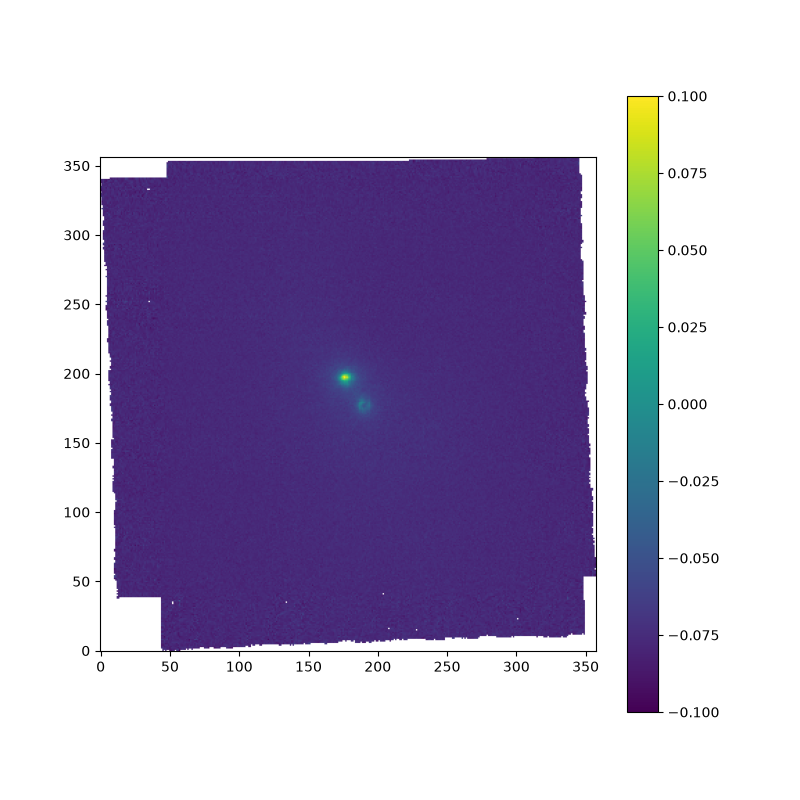

In [48]:
plt.imshow(red_moment0, origin='lower')
plt.colorbar()
plt.show()

In [44]:
blue_moment_0 = blue_cube.moment(order=0)
green_moment_0 = green_cube.moment(order=0)
red_moment_0 = red_cube.moment(order=0)

Create a function that give me coordinates when clicking in the image

In [45]:
def onclick(event):

    # Only respond to clicks inside the image
    if event.inaxes != ax:
        return

    # Pixel coordinates
    x_pixel = event.xdata
    y_pixel = event.ydata

    # Convert pixel -> world coordinates
    skycoord = blue_moment_0.wcs.pixel_to_world(
        x_pixel,
        y_pixel
    )

    print("\n-----------------------------")
    print(f"Pixel coordinates:")
    print(f"    X = {x_pixel:.2f}")
    print(f"    Y = {y_pixel:.2f}")

    print("\nWorld coordinates:")
    print(f"    RA  = {skycoord.ra.to_string(unit=u.hourangle, sep=':')}")
    print(f"    DEC = {skycoord.dec.to_string(unit=u.deg, sep=':')}")
    print("-----------------------------")

    # Display the coordinates on the image
    ax.plot(
        x_pixel,
        y_pixel,
        marker="+",
        markersize=12,
        markeredgewidth=2
    )

    ax.annotate(
        f"({x_pixel:.1f}, {y_pixel:.1f})\n"
        f"{skycoord.ra.to_string(unit=u.hourangle, sep=':')}\n"
        f"{skycoord.dec.to_string(unit=u.deg, sep=':')}",
        xy=(x_pixel, y_pixel),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    fig.canvas.draw_idle()

In [ ]:
# rgb_image = make_rgb(blue_moment_0, green_moment_0, red_moment_0,stretch=LogStretch(a=10), filename="mrk996_rgb.jpeg")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=red_cube.wcs)

im = ax.imshow(red_cube)

# Add axes labels
ax.set_xlabel("RA", fontsize=12)
ax.set_ylabel("DEC", fontsize=12)

# Add the clicky functionality
#fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

...

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

TypeError: only dimensionless scalar quantities can be converted to Python scalars

## Calculate Seeing

Obtain the pixel scale in arcseconds

In [ ]:
pixel_scales = proj_plane_pixel_scales(cube.wcs.celestial) * u.deg

scale_y, scale_x = pixel_scales.to(u.arcsec)

print(f"Pixel scale along X: {scale_x}")
print(f"Pixel scale along Y: {scale_y}")


Pixel scale along X: 0.025419999999999995 arcsec
Pixel scale along Y: 0.025189999999999994 arcsec


Define a circular aperture at the zone of peak emission of the galaxy.

In [ ]:
# Define the center position
center_pos = [177, 197]

# Define the circular mask with radius of 0.15 arcseconds
yy, xx = np.indices(center_pos, dtype='float')
radius = ((yy-2)**2 + (xx-2)**2)**0.5
mask = radius <= 2

Plot the spectrum in the point

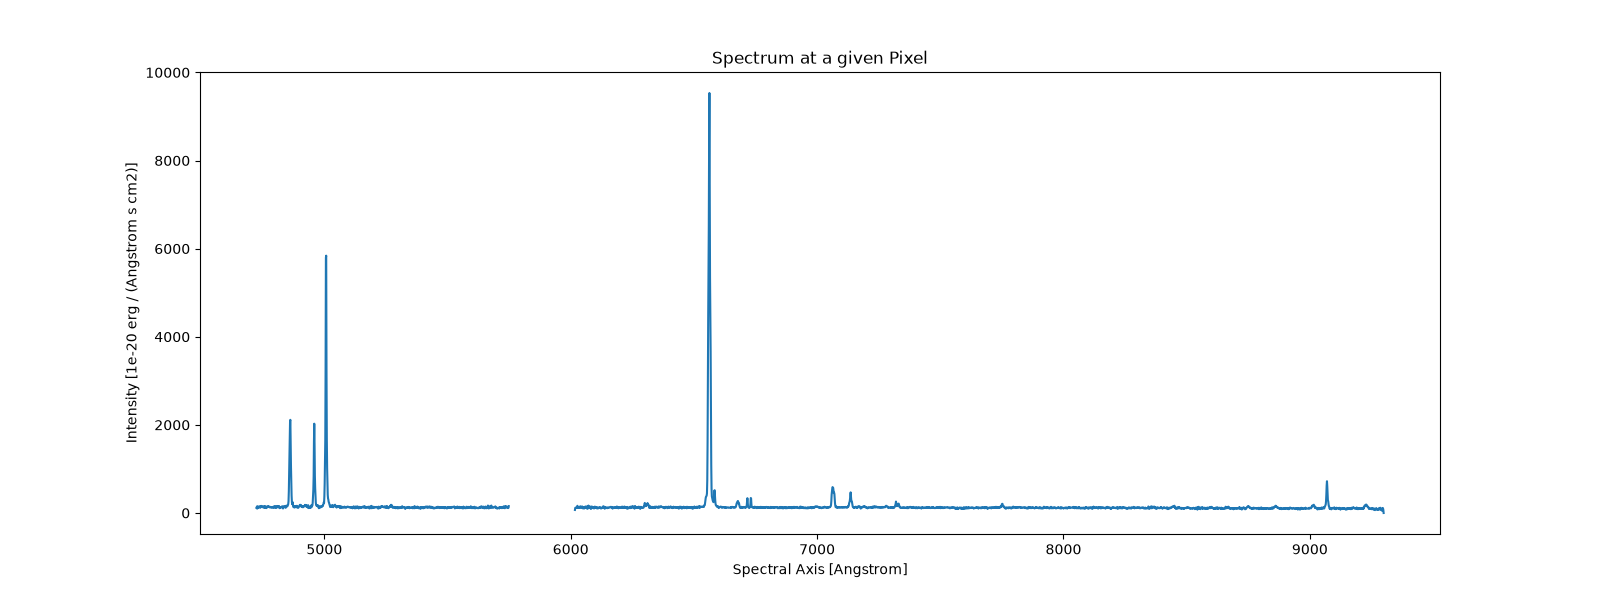

In [ ]:

z = 0.0054

point_spectrum = cube[:, center_pos[1], center_pos[0]]

axis_unit = cube.spectral_axis.unit

x_obs = cube.spectral_axis
x_rest = x_obs / (1 + z)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(x_rest.value, point_spectrum.value)


ax.set_xlabel(f"Spectral Axis [{axis_unit}]")
ax.set_ylabel(f"Intensity [{cube.unit}]")
ax.set_title("Spectrum at a given Pixel")

plt.show()

## Fit lines to spectrum

We will use either a Gaussian1D profile or a Moffat1D profile